In [5]:
# Colab setup — install PrettyMIDI and upload the raw MIDI ZIP

!pip install -q pretty_midi

import os
import gc
import shutil
import tempfile
import warnings
import zipfile
import pretty_midi

from google.colab import files

DATA_DIR = 'data'
COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']

SPLIT_COUNTS = {
    'bach': {
        'train': 42,
        'dev': 4,
        'test': 4
    },
    'beethoven': {
        'train': 42,
        'dev': 4,
        'test': 4
    },
    'chopin': {
        'train': 41,
        'dev': 4,
        'test': 4
    },
    'mozart': {
        'train': 41,
        'dev': 4,
        'test': 4
    }
}


def dataset_is_ready():
    for composer in COMPOSERS:
        for split, expected_count in SPLIT_COUNTS[composer].items():
            folder = os.path.join(
                DATA_DIR,
                split,
                composer
            )

            if not os.path.isdir(folder):
                return False

            midi_files = [
                file_name
                for file_name in os.listdir(folder)
                if file_name.lower().endswith(
                    ('.mid', '.midi')
                )
            ]

            if len(midi_files) != expected_count:
                return False

    return True


def composer_members(archive, composer):
    archive_names = archive.namelist()

    preferred_prefix = (
        f'midiclassics/{composer}/'
    )

    members = sorted([
        member
        for member in archive_names
        if member.lower().startswith(
            preferred_prefix
        )
        and member.lower().endswith(
            ('.mid', '.midi')
        )
        and not member.endswith('/')
    ])

    if members:
        return members

    fallback_prefix = f'{composer}/'

    return sorted([
        member
        for member in archive_names
        if member.lower().startswith(
            fallback_prefix
        )
        and member.lower().endswith(
            ('.mid', '.midi')
        )
        and not member.endswith('/')
    ])


if not dataset_is_ready():
    print(
        'Upload the raw MIDI dataset ZIP '
        '(archive (11).zip).'
    )

    uploaded = files.upload()

    archive_path = None

    for uploaded_name in uploaded:
        if not zipfile.is_zipfile(
            uploaded_name
        ):
            continue

        with zipfile.ZipFile(
            uploaded_name,
            'r'
        ) as archive:
            valid_archive = all(
                len(
                    composer_members(
                        archive,
                        composer
                    )
                ) >= sum(
                    SPLIT_COUNTS[
                        composer
                    ].values()
                )
                for composer in COMPOSERS
            )

        if valid_archive:
            archive_path = uploaded_name
            break

    if archive_path is None:
        raise ValueError(
            'The uploaded file is not the raw '
            'Bach, Beethoven, Chopin, and '
            'Mozart MIDI archive.'
        )

    shutil.rmtree(
        DATA_DIR,
        ignore_errors=True
    )

    with zipfile.ZipFile(
        archive_path,
        'r'
    ) as archive:

        for composer in COMPOSERS:
            members = composer_members(
                archive,
                composer
            )

            needed = sum(
                SPLIT_COUNTS[
                    composer
                ].values()
            )

            valid_members = []

            with tempfile.NamedTemporaryFile(
                suffix='.mid',
                delete=False
            ) as temporary_file:
                temporary_path = (
                    temporary_file.name
                )

            try:
                for member in members:
                    midi_bytes = archive.read(
                        member
                    )

                    with open(
                        temporary_path,
                        'wb'
                    ) as temporary_file:
                        temporary_file.write(
                            midi_bytes
                        )

                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter(
                                'ignore'
                            )

                            pretty_midi.PrettyMIDI(
                                temporary_path
                            )

                        valid_members.append(
                            member
                        )

                    except Exception:
                        continue

                    if len(valid_members) == needed:
                        break

            finally:
                if os.path.exists(
                    temporary_path
                ):
                    os.remove(
                        temporary_path
                    )

            if len(valid_members) < needed:
                raise ValueError(
                    f'Not enough readable MIDI '
                    f'files for {composer}.'
                )

            position = 0

            for split, count in (
                SPLIT_COUNTS[
                    composer
                ].items()
            ):
                output_folder = os.path.join(
                    DATA_DIR,
                    split,
                    composer
                )

                os.makedirs(
                    output_folder,
                    exist_ok=True
                )

                selected_members = (
                    valid_members[
                        position:
                        position + count
                    ]
                )

                for file_number, member in enumerate(
                    selected_members,
                    start=position + 1
                ):
                    output_path = os.path.join(
                        output_folder,
                        (
                            f'{composer}_'
                            f'{file_number:03d}.mid'
                        )
                    )

                    with archive.open(
                        member
                    ) as source_file:
                        with open(
                            output_path,
                            'wb'
                        ) as destination_file:
                            shutil.copyfileobj(
                                source_file,
                                destination_file
                            )

                position += count

    del uploaded
    gc.collect()

print('\nDataset ready:')

for split in ['train', 'dev', 'test']:
    split_counts = {
        composer: len(
            os.listdir(
                os.path.join(
                    DATA_DIR,
                    split,
                    composer
                )
            )
        )
        for composer in COMPOSERS
    }

    print(split, split_counts)



Dataset ready:
train {'bach': 42, 'beethoven': 42, 'chopin': 41, 'mozart': 41}
dev {'bach': 4, 'beethoven': 4, 'chopin': 4, 'mozart': 4}
test {'bach': 4, 'beethoven': 4, 'chopin': 4, 'mozart': 4}


# Phase 1 — Data Exploration
**AAI-511 · Composer Identification via Deep Learning**

File counts per composer across train/dev/test splits, average MIDI duration per composer, and MIDI file validation.

In [6]:
# Import libraries
import os
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


---
## Phase 2 — Data Pre-processing & Feature Extraction

Note/chord sequence extraction and tempo (`pretty_midi`), vocabulary encoding, LSTM sliding windows, CNN piano-roll windows, pitch-shift + tempo-scale augmentation, and saving preprocessed arrays.

In [16]:
# Phase 2 imports & constants!!!@@@#@
import os
import json
import warnings
import statistics
import numpy as np
import pretty_midi


# Re-declare shared constants so this phase runs independently
DATA_DIR   = 'data'
COMPOSERS  = ['bach', 'beethoven', 'chopin', 'mozart']
splits     = ['train', 'dev', 'test']

WINDOW_SIZE     = 100
STEP_SIZE       = 10
FS              = 10
TIME_STEPS      = 128
CNN_STEP        = 32
PITCH_SHIFTS    = [-2, -1, 1, 2]     # semitone shifts for CNN augmentation
TEMPO_SCALES    = [0.9, 1.1]         # time-stretch factors for CNN augmentation (0.9=faster, 1.1=slower)

COMPOSER_TO_IDX = {c: i for i, c in enumerate(COMPOSERS)}
IDX_TO_COMPOSER = {i: c for c, i in COMPOSER_TO_IDX.items()}
print("Composer → label index:", COMPOSER_TO_IDX)

Composer → label index: {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}


In [17]:
# 1. Note Sequence Extraction (+ tempo)

# extract_midi_features: read one MIDI file and return the features we need for
# modeling — the ordered list of note/chord tokens (for the LSTM) and the file's
# mean tempo in BPM (a descriptive feature). Returns a (notes, tempo) tuple.
def extract_midi_features(midi_path):
    try:
        midi   = pretty_midi.PrettyMIDI(midi_path)
        events = []
        for instr in midi.instruments:
            if instr.is_drum:
                continue
            for n in instr.notes:
                events.append((round(n.start, 3), pretty_midi.note_number_to_name(n.pitch)))
        events.sort(key=lambda e: e[0])

        notes_out = []
        i = 0
        while i < len(events):
            t0, name = events[i]
            chord = [name]
            j = i + 1
            while j < len(events) and abs(events[j][0] - t0) <= 0.05:
                chord.append(events[j][1])
                j += 1
            if len(chord) == 1:
                notes_out.append(chord[0])
            else:
                notes_out.append('.'.join(sorted(chord)))
            i = j

        tempi = midi.get_tempo_changes()[1]
        tempo = float(np.mean(tempi)) if len(tempi) else 120.0
        return notes_out, tempo
    except Exception as e:
        print(f"  Skipped {os.path.basename(midi_path)}: {e}")
        return [], 120.0

raw_sequences = {split: [] for split in splits}
tempo_records = []

for split in splits:
    print(f"\n{split}")
    for composer in COMPOSERS:
        folder = os.path.join(DATA_DIR, split, composer)
        files  = sorted(f for f in os.listdir(folder) if f.endswith('.mid'))
        ok = 0
        for fname in files:
            notes, tempo = extract_midi_features(os.path.join(folder, fname))
            if notes:
                raw_sequences[split].append((composer, notes))
                tempo_records.append((split, composer, tempo))
                ok += 1
        print(f"  {composer}: {ok}/{len(files)} files extracted")

print("\nExtraction complete.")
print("\nMean tempo per composer (train, BPM):")
for composer in COMPOSERS:
    tempi = [t for s, c, t in tempo_records if s == 'train' and c == composer]
    if tempi:
        print(f"  {composer:10s}: {np.mean(tempi):6.1f}  (n={len(tempi)})")


train
  bach: 42/42 files extracted


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


  beethoven: 42/42 files extracted
  chopin: 41/41 files extracted
  mozart: 41/41 files extracted

dev
  bach: 4/4 files extracted
  beethoven: 4/4 files extracted
  chopin: 4/4 files extracted
  mozart: 4/4 files extracted

test
  bach: 4/4 files extracted
  beethoven: 4/4 files extracted
  chopin: 4/4 files extracted
  mozart: 4/4 files extracted

Extraction complete.

Mean tempo per composer (train, BPM):
  bach      :  100.3  (n=42)
  beethoven :  119.6  (n=42)
  chopin    :  111.1  (n=41)
  mozart    :   92.9  (n=41)


In [18]:
# 2. Vocabulary & Integer Encoding  (built from train split only — no leakage)
# Tokens indexed from 1; 0 is reserved as OOV/mask for the LSTM Embedding.
all_train_notes = [n for _, notes in raw_sequences['train'] for n in notes]
vocab           = sorted(set(all_train_notes))
note_to_int     = {n: i + 1 for i, n in enumerate(vocab)}
int_to_note     = {i: n for n, i in note_to_int.items()}
vocab_size      = len(vocab)

print(f"Vocabulary size : {vocab_size} unique notes/chords (indices 1–{vocab_size}; 0 = OOV)")
print(f"Sample elements : {vocab[:10]}")

with open('vocab.json', 'w') as f:
    json.dump({
        'note_to_int': note_to_int,
        'int_to_note': {str(k): v for k, v in int_to_note.items()},
        'composers':   COMPOSERS
    }, f, indent=2)
print("Saved vocab.json")

Vocabulary size : 24837 unique notes/chords (indices 1–24837; 0 = OOV)
Sample elements : ['A#0.A#1.A#2', 'A#0.A#1.A#2.D#4.D#4.D#5.G4.G4.G5', 'A#1', 'A#1.A#1', 'A#1.A#1.A#2', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#3.A#3.A#3.A#4.A#4.A#4.A#4.A#4.A#5.A#5', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#3.A#4.A#4.A#4.A#4.A#5.A#5.A#5', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#3.A#4.A#4.A#4.A#5.D4.D4.D5.D5.F6', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#4.D4.F5.F5.F6', 'A#1.A#1.A#2.A#2.A#2.A#3.A#3.A#3.A#3.A#4.A#4.A#4.A#4.A#4']
Saved vocab.json


In [11]:
# 3. LSTM Sliding Windows
def make_lstm_windows(sequences, note_to_int, window=WINDOW_SIZE, step=STEP_SIZE):
    """Convert (composer, notes) pairs into (X, y) arrays for LSTM classification."""
    X, y = [], []
    for composer, notes in sequences:
        encoded = [note_to_int.get(n, 0) for n in notes]  # 0 = out-of-vocabulary
        label   = COMPOSER_TO_IDX[composer]
        for i in range(0, len(encoded) - window, step):
            X.append(encoded[i : i + window])
            y.append(label)
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X_lstm, y_lstm = {}, {}
for split in splits:
    X_lstm[split], y_lstm[split] = make_lstm_windows(raw_sequences[split], note_to_int)
    print(f"{split:6s}  X={X_lstm[split].shape}  y={y_lstm[split].shape}")

print(f"\nInput shape per sample : ({WINDOW_SIZE},)  →  vocab_size={vocab_size}")

train   X=(13941, 100)  y=(13941,)
dev     X=(2927, 100)  y=(2927,)
test    X=(2076, 100)  y=(2076,)

Input shape per sample : (100,)  →  vocab_size=24837


In [19]:
# 4. CNN Piano-Roll Windows

# random CNN split stops similar songs grouping together
rng=np.random.default_rng(42)

cnn_files={
    split:{composer:[] for composer in COMPOSERS}
    for split in splits
}

for composer in COMPOSERS:
    all_files=[]

    for old_split in splits:
        folder=os.path.join(
            DATA_DIR,
            old_split,
            composer
        )

        all_files.extend([
            os.path.join(folder,fname)
            for fname in os.listdir(folder)
            if fname.endswith('.mid')
        ])

    all_files=sorted(all_files)
    rng.shuffle(all_files)

    cnn_files['train'][composer]=all_files[:-8]
    cnn_files['dev'][composer]=all_files[-8:-4]
    cnn_files['test'][composer]=all_files[-4:]

    print(
        composer,
        len(cnn_files['train'][composer]),
        len(cnn_files['dev'][composer]),
        len(cnn_files['test'][composer])
    )


def make_cnn_windows(
    split,
    fs=FS,
    time_steps=TIME_STEPS,
    step=CNN_STEP
):
    X,y=[],[]

    for composer in COMPOSERS:
        label=COMPOSER_TO_IDX[composer]

        for midi_path in cnn_files[split][composer]:
            try:
                midi=pretty_midi.PrettyMIDI(midi_path)
                roll=midi.get_piano_roll(fs=fs)

                roll=np.clip(
                    roll/127.0,
                    0.0,
                    1.0
                )

                total=roll.shape[1]
                added=0

                for start in range(
                    0,
                    total-time_steps+1,
                    step
                ):
                    X.append(
                        roll[:,start:start+time_steps]
                    )

                    y.append(label)
                    added+=1

                if added==0:
                    pad=np.zeros(
                        (128,time_steps),
                        dtype=np.float32
                    )

                    pad[:,:total]=roll
                    X.append(pad)
                    y.append(label)

            except Exception as e:
                print("Skipped",os.path.basename(midi_path),e)

    X=np.array(
        X,
        dtype=np.float32
    )[...,np.newaxis]

    y=np.array(
        y,
        dtype=np.int32
    )

    return X,y


X_cnn={}
y_cnn={}

for split in splits:
    X_cnn[split],y_cnn[split]=make_cnn_windows(
        split
    )

    print(
        split,
        "X=",X_cnn[split].shape,
        "y=",y_cnn[split].shape
    )

print(
    "\nInput shape:",
    (128,TIME_STEPS,1)
)

bach 42 4 4
beethoven 42 4 4
chopin 41 4 4
mozart 41 4 4
train X= (9998, 128, 128, 1) y= (9998,)
dev X= (1299, 128, 128, 1) y= (1299,)
test X= (821, 128, 128, 1) y= (821,)

Input shape: (128, 128, 1)


In [20]:
# 5. balance CNN data then augment train windows

def pitch_shift(sample,semitones):
    roll=sample[:,:,0]
    shifted=np.zeros_like(roll)

    if semitones>0:
        shifted[semitones:,:]=roll[:-semitones,:]

    elif semitones<0:
        shifted[:semitones,:]=roll[-semitones:,:]

    else:
        shifted=roll.copy()

    return shifted[...,np.newaxis]


def time_stretch(sample,factor):
    roll=sample[:,:,0]
    T=roll.shape[1]

    new_T=max(
        1,
        int(round(T*factor))
    )

    indexes=np.linspace(
        0,
        T-1,
        new_T
    ).astype(int)

    warped=roll[:,indexes]

    output=np.zeros(
        (128,T),
        dtype=roll.dtype
    )

    if new_T>=T:
        output[:]=warped[:,:T]
    else:
        output[:,:new_T]=warped

    return output[...,np.newaxis]


# keep more Mozart instead of cutting everything to Bach
rng=np.random.default_rng(42)

class_counts=np.bincount(
    y_cnn['train'],
    minlength=4
)

TARGET_PER_CLASS=2000
balanced_indexes=[]

for label in range(4):
    label_indexes=np.where(
        y_cnn['train']==label
    )[0]

    selected=rng.choice(
        label_indexes,
        size=TARGET_PER_CLASS,
        replace=len(label_indexes)<TARGET_PER_CLASS
    )

    balanced_indexes.extend(selected)

balanced_indexes=np.array(
    balanced_indexes,
    dtype=np.int32
)

rng.shuffle(balanced_indexes)

base_X=list(
    X_cnn['train'][balanced_indexes]
)

base_y=list(
    y_cnn['train'][balanced_indexes]
)

print("Before balance:",class_counts)

print(
    "After balance:",
    np.bincount(
        np.array(base_y),
        minlength=4
    )
)


# make pitch and tempo copies from balanced data
X_aug=list(base_X)
y_aug=list(base_y)

for shift in PITCH_SHIFTS:
    for sample,label in zip(base_X,base_y):
        X_aug.append(
            pitch_shift(sample,shift)
        )
        y_aug.append(label)

for scale in TEMPO_SCALES:
    for sample,label in zip(base_X,base_y):
        X_aug.append(
            time_stretch(sample,scale)
        )
        y_aug.append(label)

X_cnn['train']=np.array(
    X_aug,
    dtype=np.float32
)

y_cnn['train']=np.array(
    y_aug,
    dtype=np.int32
)

print(
    "Final class counts:",
    np.bincount(
        y_cnn['train'],
        minlength=4
    )
)

print(
    "CNN train after augmentation:",
    X_cnn['train'].shape
)

Before balance: [ 660 3871 1922 3545]
After balance: [2000 2000 2000 2000]
Final class counts: [14000 14000 14000 14000]
CNN train after augmentation: (56000, 128, 128, 1)


In [21]:
# 6. Save preprocessed arrays
os.makedirs('preprocessed', exist_ok=True)

np.savez_compressed('preprocessed/lstm_data.npz',
    X_train = X_lstm['train'], y_train = y_lstm['train'],
    X_dev   = X_lstm['dev'],   y_dev   = y_lstm['dev'],
    X_test  = X_lstm['test'],  y_test  = y_lstm['test'])

np.savez_compressed('preprocessed/cnn_data.npz',
    X_train = X_cnn['train'],  y_train = y_cnn['train'],
    X_dev   = X_cnn['dev'],    y_dev   = y_cnn['dev'],
    X_test  = X_cnn['test'],   y_test  = y_cnn['test'])

print("Saved preprocessed/lstm_data.npz")
print(f"  train {X_lstm['train'].shape} | dev {X_lstm['dev'].shape} | test {X_lstm['test'].shape}")
print("Saved preprocessed/cnn_data.npz")
print(f"  train {X_cnn['train'].shape} | dev {X_cnn['dev'].shape} | test {X_cnn['test'].shape}")

Saved preprocessed/lstm_data.npz
  train (13941, 100) | dev (2927, 100) | test (2076, 100)
Saved preprocessed/cnn_data.npz
  train (56000, 128, 128, 1) | dev (1299, 128, 128, 1) | test (821, 128, 128, 1)


---
## Phase 4 — CNN Model

2D CNN treating piano-roll windows as grayscale images (128 pitches × 128 frames × 1 channel).  
Trained on 114,548 augmented windows (7× pitch-shift + tempo-scale augmentation).

CNN train: (56000, 128, 128, 1)
CNN dev: (1299, 128, 128, 1)
CNN test: (821, 128, 128, 1)
Class counts: [14000 14000 14000 14000]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,884 (4.92 MB)

 Trainable params: 1,290,180 (4.92 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4854 - loss: 1.2121
Epoch 1: val_accuracy improved from None to 0.55812, saving model to preprocessed/cnn_best.keras

Epoch 1: finished saving model to preprocessed/cnn_best.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - accuracy: 0.5747 - loss: 0.9731 - val_accuracy: 0.5581 - val_loss: 1.1657 - learning_rate: 3.0000e-04
Epoch 2/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7219 - loss: 0.6785
Epoch 2: val_accuracy improved from 0.55812 to 0.61663, saving model to preprocessed/cnn_best.keras

Epoch 2: finished saving model to preprocessed/cnn_best.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.7534 - loss: 0.6075 - val_accuracy: 0.6166 - val_loss: 1.2099 - learning_rate: 3.0000e-04
Epoch 3/60
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8162 - loss: 0.4639
Epoch 3: val_accuracy did not improve from 0.61663
875/875 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.8350 - loss: 0

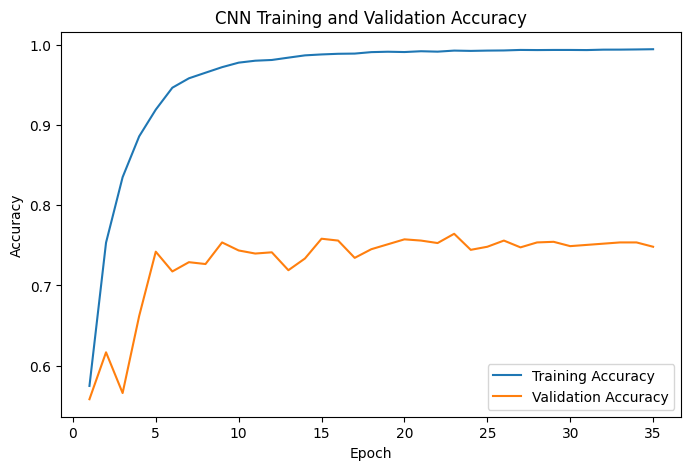

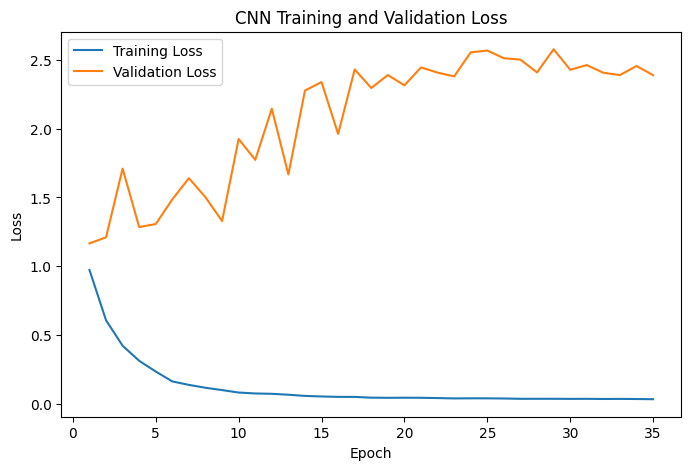

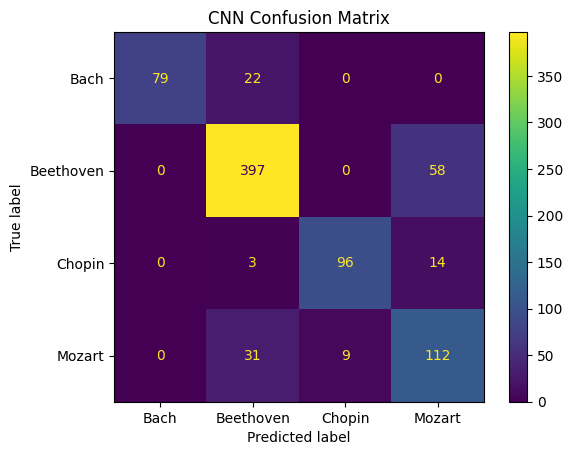

In [22]:
# Phase 4 CNN model training and evaluation

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D
from tensorflow.keras.layers import BatchNormalization,Dropout
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# load balanced CNN arrays from phase 2
X_train_cnn=X_cnn['train']
y_train_cnn=y_cnn['train']

X_dev_cnn=X_cnn['dev']
y_dev_cnn=y_cnn['dev']

X_test_cnn=X_cnn['test']
y_test_cnn=y_cnn['test']
print("CNN train:",X_train_cnn.shape)
print("CNN dev:",X_dev_cnn.shape)
print("CNN test:",X_test_cnn.shape)
print(
    "Class counts:",
    np.bincount(
        y_train_cnn,
        minlength=4)
)

# send data in batches so colab stays stable
class CNNSequence(tf.keras.utils.Sequence):

    def __init__(self,X,y,batch_size=64,shuffle=False):
        super().__init__()

        self.X=X
        self.y=y
        self.batch_size=batch_size
        self.shuffle=shuffle
        self.indexes=np.arange(len(X))

        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(
                len(self.X)/self.batch_size
            )
        )

    def __getitem__(self,index):
        start=index*self.batch_size
        end=start+self.batch_size

        batch_indexes=self.indexes[start:end]

        X_batch=np.asarray(
            self.X[batch_indexes],
            dtype=np.float32
        )

        y_batch=np.asarray(
            self.y[batch_indexes],
            dtype=np.int32
        )

        return X_batch,y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(
                self.indexes
            )


BATCH_SIZE=64
MAX_EPOCHS=60


train_data_cnn=CNNSequence(
    X_train_cnn,
    y_train_cnn,
    BATCH_SIZE,
    shuffle=True
)

dev_data_cnn=CNNSequence(
    X_dev_cnn,
    y_dev_cnn,
    BATCH_SIZE
)

test_data_cnn=CNNSequence(
    X_test_cnn,
    y_test_cnn,
    BATCH_SIZE
)

# deeper blocks learn stronger piano roll patterns
model_cnn=Sequential([
    Input(
        shape=X_train_cnn.shape[1:]
    ),

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.20),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.35),

    Flatten(),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.0001)
    ),

    Dropout(0.50),

    Dense(
        4,
        activation='softmax'
    )
])


model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()


# stop when validation accuracy quits getting better
callbacks_cnn=[
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=0.00001,
        verbose=1
    ),

    ModelCheckpoint(
        'preprocessed/cnn_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_cnn=model_cnn.fit(
    train_data_cnn,
    validation_data=dev_data_cnn,
    epochs=MAX_EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1)


# test the restored best model on unseen windows
dev_loss,dev_accuracy=model_cnn.evaluate(
    dev_data_cnn,
    verbose=0)

test_loss,test_accuracy=model_cnn.evaluate(
    test_data_cnn,
    verbose=0)

best_epoch=np.argmax(
    history_cnn.history['val_accuracy']
)+1


print("\nBest epoch:",best_epoch)
print("Dev accuracy:",round(dev_accuracy,4))
print("Test accuracy:",round(test_accuracy,4))
print("Test loss:",round(test_loss,4))


# get predictions for every CNN test window
test_probabilities=model_cnn.predict(
    test_data_cnn,
    verbose=0)

test_predictions=np.argmax(
    test_probabilities,
    axis=1
)

test_labels=np.asarray(
    y_test_cnn,
    dtype=np.int32
)


# calculate the four required evaluation scores
accuracy=accuracy_score(
    test_labels,
    test_predictions
)

precision=precision_score(
    test_labels,
    test_predictions,
    average='weighted',
    zero_division=0
)

recall=recall_score(
    test_labels,
    test_predictions,
    average='weighted',
    zero_division=0
)

f1=f1_score(
    test_labels,
    test_predictions,
    average='weighted',
    zero_division=0
)


print("\nCNN Evaluation Results")
print("Accuracy:",round(accuracy,4))
print("Precision:",round(precision,4))
print("Recall:",round(recall,4))
print("F1-score:",round(f1,4))


composer_names=[
    'Bach',
    'Beethoven',
    'Chopin',
    'Mozart'
]


# show results for each composer separately
print("\nClassification Report\n")

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=composer_names,
        zero_division=0
    )
)


# show accuracy during model training
epochs=range(
    1,
    len(history_cnn.history['accuracy'])+1
)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    epochs,
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()


# show loss during model training
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    epochs,
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()


# show which composers the model confused most
matrix=confusion_matrix(
    test_labels,
    test_predictions
)

display=ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=composer_names
)

display.plot(
    values_format='d'
)

plt.title('CNN Confusion Matrix')
plt.show()